# Homework 4: Decision Trees and Neural Networks (SOLVED)

This homework focuses on implementing core concepts in machine learning:
- **Part 1**: Entropy, Information Gain, and Decision Tree Implementation
- **Part 2**: Neural Network Forward Pass and Backpropagation
- **Part 3**: Extra Credit - Ensemble Methods and PyTorch

**Due Date**: Monday, March 23rd, 2026 (11:59 PM)

**Total Points**: 100 points + 30 extra credit points

# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Part 1 - Decision Trees (50 Points)

In this section you will implement entropy, information gain, and a complete decision tree classifier from scratch.

## Background

Decision trees recursively split data based on features to minimize impurity. For classification, we use **entropy** as our impurity measure.

**Entropy** measures the uncertainty in a set of labels:

$$H(Y) = -\sum_{c} p(c) \log_2 p(c)$$

where $p(c)$ is the probability of class $c$. Entropy is 0 for pure nodes (all same class) and maximum for uniform distributions.

**Information Gain** measures how much a feature reduces entropy:

$$IG(Y, X_j) = H(Y) - H(Y \mid X_j)$$

where the conditional entropy is:

$$H(Y \mid X_j) = \sum_{v} P(X_j = v) \cdot H(Y \mid X_j = v)$$

We choose splits that maximize information gain.

In [ ]:
# Toy dataset for decision tree questions
# Scenario: Predicting whether a student passes (1) or fails (0) based on:
# - Feature 0: Has_HW_Submitted (1=Yes, 0=No)
# - Feature 1: Attended_Review (1=Yes, 0=No)

X_dt = np.array([
    [1, 1],  # Submitted HW, Attended Review
    [1, 0],  # Submitted HW, Did not attend
    [1, 1],  # Submitted HW, Attended Review
    [0, 1],  # Did not submit HW, Attended Review
    [0, 0],  # Did not submit HW, Did not attend
    [0, 1],  # Did not submit HW, Attended Review
    [1, 0],  # Submitted HW, Did not attend
    [0, 0],  # Did not submit HW, Did not attend
], dtype=int)

y_dt = np.array([1, 1, 1, 0, 0, 0, 1, 1], dtype=int)

feature_names = ["Has_HW_Submitted", "Attended_Review"]

print('Dataset Information:')
print('  X_dt shape:', X_dt.shape)
print('  y_dt shape:', y_dt.shape)
print('  Features:', feature_names)
print('  Class distribution:', {0: int(np.sum(y_dt == 0)), 1: int(np.sum(y_dt == 1))})
print('\nFirst 3 samples:')
for i in range(3):
    print(f'  Sample {i}: {feature_names[0]}={X_dt[i,0]}, {feature_names[1]}={X_dt[i,1]}, Pass={y_dt[i]}')

## Question 1.1 - Implement Entropy (8 Points)

Implement the function `entropy(y)` that computes the entropy of a set of labels.

**Requirements:**
1. Return entropy in **base-2** (bits)
2. Handle pure nodes correctly (entropy should be 0 when all labels are the same)
3. Avoid numerical issues with $\log_2(0)$ by skipping terms where probability is 0
4. Support multi-class labels (not just binary)

**Formula:**
$$H(Y) = -\sum_{c \in \text{classes}} p(c) \log_2 p(c)$$

where $p(c)$ is the fraction of samples with label $c$.

In [4]:
###############################################
############ Question 1.1 - 8 pts ############
###############################################

################################################
########## SOLUTION ###########################
################################################

def entropy(y):
    """
    Compute entropy H(Y) in bits for a 1D array of class labels.
    
    Parameters
    ----------
    y : np.ndarray, shape (n,)
        Array of class labels (can be any hashable type)
    
    Returns
    -------
    float
        Entropy in bits (base-2)
    """
    # Find unique classes and their counts
    unique_classes, counts = np.unique(y, return_counts=True)
    
    # Convert counts to probabilities
    probabilities = counts / len(y)
    
    # Compute entropy (only include terms where p > 0)
    entropy_value = 0.0
    for p in probabilities:
        if p > 0:  # Avoid log(0)
            entropy_value -= p * np.log2(p)
    
    return entropy_value

################################################
########## End of solution ####################
################################################

# Test cases
print('Test Cases for Entropy:')
print('=' * 50)
print(f'entropy([0,0,0,0])     = {entropy(np.array([0, 0, 0, 0])):.4f}  (expected: 0.0000)')
print(f'entropy([0,1])         = {entropy(np.array([0, 1])):.4f}  (expected: 1.0000)')
print(f'entropy([0,1,0,1])     = {entropy(np.array([0, 1, 0, 1])):.4f}  (expected: 1.0000)')
print(f'entropy([0,0,0,1])     = {entropy(np.array([0, 0, 0, 1])):.4f}  (expected: 0.8113)')
print(f'entropy(y_dt)          = {entropy(y_dt):.4f}  (expected: 0.9544)')
print(f'entropy([0,1,2])       = {entropy(np.array([0, 1, 2])):.4f}  (expected: 1.5850)')

Test Cases for Entropy:
entropy([0,0,0,0])     = 0.0000  (expected: 0.0000)
entropy([0,1])         = 1.0000  (expected: 1.0000)
entropy([0,1,0,1])     = 1.0000  (expected: 1.0000)
entropy([0,0,0,1])     = 0.8113  (expected: 0.8113)
entropy(y_dt)          = 1.0000  (expected: 0.9544)
entropy([0,1,2])       = 1.5850  (expected: 1.5850)


## Question 1.2 - Conditional Entropy and Information Gain (10 Points)

Implement `information_gain(X, y, feature_idx)` to compute the information gain for a given feature.

**Conditional Entropy** measures the remaining entropy after splitting on feature $X_j$:

$$H(Y \mid X_j) = \sum_{v \in \text{values}} P(X_j = v) \cdot H(Y \mid X_j = v)$$

**Information Gain** is the reduction in entropy:

$$IG(Y, X_j) = H(Y) - H(Y \mid X_j)$$

**Requirements:**
1. Handle features with any number of unique values (not just binary)
2. Weight each child's entropy by the fraction of samples in that split
3. Return the information gain as a non-negative value

In [ ]:
###############################################
########### Question 1.2 - 10 pts ############
###############################################

def split_indices(X, feature_idx, value):
    """Return row indices where X[:, feature_idx] == value."""
    return np.where(X[:, feature_idx] == value)[0]

################################################
########## SOLUTION ###########################
################################################

def information_gain(X, y, feature_idx):
    """
    Compute IG(Y, X_j) for the feature at column feature_idx.
    
    Parameters
    ----------
    X : np.ndarray, shape (n, d)
        Feature matrix
    y : np.ndarray, shape (n,)
        Labels
    feature_idx : int
        Index of the feature to compute IG for
        
    Returns
    -------
    float
        Information gain in bits
    """
    # Step 1: Compute parent entropy
    parent_entropy = entropy(y)
    
    # Step 2: Compute weighted conditional entropy
    conditional_entropy = 0.0
    
    # Get all unique values in the feature
    unique_values = np.unique(X[:, feature_idx])
    
    # For each unique value
    for value in unique_values:
        # Get indices where the feature has this value
        indices = split_indices(X, feature_idx, value)
        
        # Get corresponding labels
        y_subset = y[indices]
        
        # Compute probability of this value: P(X_j = v)
        prob = len(indices) / len(y)
        
        # Compute entropy of labels in this subset
        subset_entropy = entropy(y_subset)
        
        # Add weighted entropy
        conditional_entropy += prob * subset_entropy
    
    # Step 3: Return information gain
    return parent_entropy - conditional_entropy

################################################
########## End of solution ####################
################################################

# Test on the toy dataset
print('Information Gain for each feature:')
print('=' * 50)
for j, name in enumerate(feature_names):
    ig = information_gain(X_dt, y_dt, j)
    print(f'  {name:20s}: IG = {ig:.4f}')
    
print('\nExpected values:')
print('  Has_HW_Submitted    : IG ≈ 0.5488')
print('  Attended_Review     : IG ≈ 0.0488')

## Question 1.3 - Select Best Root Split (7 Points)

Use your `information_gain` function to choose the best feature for the root node.

**Tasks:**
1. Compute information gain for each feature
2. Select the feature with maximum information gain
3. Print the best feature name and its IG value
4. Explain why this feature is intuitively better for prediction

In [6]:
###############################################
############ Question 1.3 - 7 pts ############
###############################################

################################################
########## SOLUTION ###########################
################################################

# Compute IG for each feature
ig_values = []
for j in range(X_dt.shape[1]):
    ig = information_gain(X_dt, y_dt, j)
    ig_values.append(ig)

# Find the index of the feature with maximum IG
best_feature_idx = np.argmax(ig_values)

print('Feature Information Gains:')
print('=' * 50)
for j, name in enumerate(feature_names):
    marker = ' <-- BEST' if j == best_feature_idx else ''
    print(f'  {name:20s}: IG = {ig_values[j]:.4f}{marker}')

print('\n' + '=' * 50)
print(f'Best feature for root split: {feature_names[best_feature_idx]}')
print(f'Information Gain: {ig_values[best_feature_idx]:.4f}')
print('\nInterpretation:')
print('The "Has_HW_Submitted" feature is the best predictor because it provides')
print('more information about whether a student will pass. Students who submit')
print('homework have a stronger tendency to pass, making this feature more')
print('discriminative than simply attending the review session.')

################################################
########## End of solution ####################
################################################

Feature Information Gains:
  Has_HW_Submitted    : IG = 1.0000 <-- BEST
  Attended_Review     : IG = 0.0000

Best feature for root split: Has_HW_Submitted
Information Gain: 1.0000

Interpretation:
The "Has_HW_Submitted" feature is the best predictor because it provides
more information about whether a student will pass. Students who submit
homework have a stronger tendency to pass, making this feature more
discriminative than simply attending the review session.


## Question 1.4 - Conceptual Questions on Decision Trees (10 Points)

Answer the following questions briefly (2-3 sentences each):

**a) Overfitting and Tree Depth (2 pts):** Why do very deep decision trees tend to overfit? How does limiting the maximum depth act as a form of regularization?

**b) Gini vs Entropy (3 pts):** Gini impurity is another splitting criterion: $\text{Gini} = 1 - \sum_c p(c)^2$. Compare Gini and entropy: When would they lead to similar splits? Can you describe a scenario where they might differ?

**c) Handling Continuous Features (3 pts):** Our implementation assumes features are discrete (categorical). How would you modify the algorithm to handle continuous features like age or temperature? What computational challenge does this introduce?

**d) Missing Values (2 pts):** How would you handle missing feature values during training? During prediction?

**SOLUTIONS:**

**a) Overfitting and Tree Depth:**

Very deep decision trees tend to overfit because they create extremely specific rules that fit the training data noise rather than the underlying patterns. Each additional split can memorize individual training samples or small groups, reducing training error but harming generalization. Limiting maximum depth acts as regularization by preventing the tree from creating overly complex decision boundaries, forcing it to learn only the most important patterns that generalize to new data.

**b) Gini vs Entropy:**

Gini impurity and entropy are highly correlated and typically lead to similar splits in practice, as both measure node impurity. They agree most when choosing between very pure and very impure splits. However, entropy is slightly more sensitive to probability changes and tends to produce more balanced trees, while Gini is computationally faster (no logarithm) and sometimes produces slightly more skewed splits. The differences are usually minor in practice, and the choice often comes down to computational efficiency (Gini) versus theoretical interpretability (entropy as information content).

**c) Handling Continuous Features:**

For continuous features, we would sort the feature values and consider split points between consecutive values (or at midpoints between consecutive unique values). For each potential threshold, we'd evaluate the information gain from splitting samples into "feature ≤ threshold" and "feature > threshold" groups. The main computational challenge is that a feature with n unique values requires evaluating O(n) potential split points, compared to just one split for binary categorical features. This makes continuous features much more expensive to process, especially with large datasets, often requiring heuristics like binning or sampling candidate thresholds.

**d) Missing Values:**

During training, we could treat missing values as a separate category, split them proportionally based on other samples (surrogate splits), or ignore samples with missing values for that feature's split calculation. During prediction, we could use the same approach (treat as a category), or traverse both branches and weight predictions by the probability of each path, or use surrogate features (backup features that correlate with the missing feature).

## Question 1.5 - Implement a Decision Tree Classifier (15 Points)

Now you'll implement a complete decision tree classifier from scratch. Your tree will recursively split nodes based on maximum information gain.

**Algorithm:**
1. Start with all data at the root
2. If stopping criterion is met (max depth, pure node, or no features left), make a leaf node
3. Otherwise, find the best feature using information gain
4. Split the data based on that feature's values
5. Recursively build subtrees for each split

**Implementation Notes:**
- A leaf node predicts the majority class in its data
- Store the tree structure using nested dictionaries
- Each internal node stores: `feature_idx`, `feature_name`, and `children` dict
- Each leaf node stores: `leaf` (True) and `prediction`

In [7]:
###############################################
############ Question 1.5 - 15 pts ###########
###############################################

################################################
########## SOLUTION ###########################
################################################

class DecisionTree:
    def __init__(self, max_depth=5):
        """
        Initialize a decision tree classifier.
        
        Parameters
        ----------
        max_depth : int
            Maximum depth of the tree (root is depth 0)
        """
        self.max_depth = max_depth
        self.tree = None
        self.feature_names = None
    
    def fit(self, X, y, feature_names=None):
        """
        Build the decision tree.
        
        Parameters
        ----------
        X : np.ndarray, shape (n, d)
            Feature matrix
        y : np.ndarray, shape (n,)
            Labels
        feature_names : list of str, optional
            Names of features for display
        """
        self.feature_names = feature_names
        self.tree = self._build_tree(X, y, depth=0)
    
    def _build_tree(self, X, y, depth):
        """
        Recursively build the decision tree.
        
        Returns a dict representing a node:
        - Leaf: {'leaf': True, 'prediction': class}
        - Internal: {'feature_idx': idx, 'feature_name': name, 'children': {value: subtree}}
        """
        n_samples, n_features = X.shape
        
        # Compute majority class for this node
        majority_class = np.bincount(y.astype(int)).argmax()
        
        # Stopping criteria: return a leaf node if any of these are true
        if (depth >= self.max_depth or 
            n_samples <= 1 or 
            n_features == 0 or 
            entropy(y) == 0):  # Pure node
            return {
                'leaf': True,
                'prediction': majority_class
            }
        
        # Find the best feature to split on
        best_ig = -1
        best_feature_idx = None
        
        for j in range(n_features):
            ig = information_gain(X, y, j)
            if ig > best_ig:
                best_ig = ig
                best_feature_idx = j
        
        # If no information gain, return a leaf
        if best_ig == 0 or best_feature_idx is None:
            return {
                'leaf': True,
                'prediction': majority_class
            }
        
        # Split the data based on the best feature
        children = {}
        feature_values = np.unique(X[:, best_feature_idx])
        
        for value in feature_values:
            # Get indices where X[:, best_feature_idx] == value
            indices = split_indices(X, best_feature_idx, value)
            
            # Remove the feature we just split on from the child data
            # This prevents reusing the same feature
            feature_mask = np.ones(n_features, dtype=bool)
            feature_mask[best_feature_idx] = False
            X_child = X[indices][:, feature_mask]
            y_child = y[indices]
            
            # Recursively build the subtree
            children[value] = self._build_tree(X_child, y_child, depth + 1)
        
        # Get feature name for display
        if self.feature_names is not None:
            feature_name = self.feature_names[best_feature_idx]
        else:
            feature_name = f"Feature_{best_feature_idx}"
        
        return {
            'feature_idx': best_feature_idx,
            'feature_name': feature_name,
            'children': children
        }
    
    def predict_single(self, x, node=None, removed_features=None):
        """
        Predict the class for a single sample.
        
        Parameters
        ----------
        x : np.ndarray, shape (d,)
            Feature vector
        node : dict, optional
            Current node (defaults to root)
        removed_features : list of int, optional
            Indices of features that have been removed in ancestor nodes
        """
        if node is None:
            node = self.tree
            removed_features = []
        
        # Base case: leaf node
        if node.get('leaf', False):
            return node['prediction']
        
        # Recursive case: internal node
        feature_idx = node['feature_idx']
        
        # Adjust index based on previously removed features
        adjusted_idx = feature_idx
        for removed in sorted(removed_features):
            if removed <= feature_idx:
                adjusted_idx += 1
        
        feature_value = x[adjusted_idx]
        
        # Navigate to the appropriate child
        if feature_value in node['children']:
            child_node = node['children'][feature_value]
            new_removed = removed_features + [adjusted_idx]
            return self.predict_single(x, child_node, new_removed)
        else:
            # Value not seen during training - return majority class from a child
            first_child = node['children'][list(node['children'].keys())[0]]
            if first_child.get('leaf', False):
                return first_child['prediction']
            return self.predict_single(x, first_child, removed_features + [adjusted_idx])
    
    def predict(self, X):
        """Predict classes for multiple samples."""
        return np.array([self.predict_single(x) for x in X])
    
    def print_tree(self, node=None, depth=0, value=None):
        """Print the tree structure in a readable format."""
        if node is None:
            node = self.tree
            print('Decision Tree Structure:')
            print('=' * 50)
        
        indent = '  ' * depth
        
        if node.get('leaf', False):
            print(f'{indent}└─ Predict: {node["prediction"]}')
        else:
            if value is not None:
                print(f'{indent}└─ [{node["feature_name"]} = {value}]')
                indent += '  '
            else:
                print(f'{indent}Split on: {node["feature_name"]}')
            
            for val, child in node['children'].items():
                self.print_tree(child, depth + 1, val)

################################################
########## End of solution ####################
################################################

# Train and evaluate the decision tree
print('Training Decision Tree...\n')
dt = DecisionTree(max_depth=3)
dt.fit(X_dt, y_dt, feature_names=feature_names)

# Print the tree structure
dt.print_tree()

# Evaluate on training data
y_pred_dt = dt.predict(X_dt)
accuracy_dt = np.mean(y_pred_dt == y_dt)
print(f'\nTraining Accuracy: {accuracy_dt:.4f}')

# Show predictions vs actual
print('\nPredictions vs Actual:')
print('=' * 50)
for i in range(len(y_dt)):
    status = 'Correct' if y_pred_dt[i] == y_dt[i] else 'Wrong'
    print(f'  Sample {i}: Features={X_dt[i]}, Predicted={y_pred_dt[i]}, Actual={y_dt[i]} [{status}]')

Training Decision Tree...

Decision Tree Structure:
Split on: Has_HW_Submitted
  └─ Predict: 0
  └─ Predict: 1

Training Accuracy: 1.0000

Predictions vs Actual:
  Sample 0: Features=[1 1], Predicted=1, Actual=1 [Correct]
  Sample 1: Features=[1 0], Predicted=1, Actual=1 [Correct]
  Sample 2: Features=[1 1], Predicted=1, Actual=1 [Correct]
  Sample 3: Features=[0 1], Predicted=0, Actual=0 [Correct]
  Sample 4: Features=[0 0], Predicted=0, Actual=0 [Correct]
  Sample 5: Features=[0 1], Predicted=0, Actual=0 [Correct]
  Sample 6: Features=[1 0], Predicted=1, Actual=1 [Correct]
  Sample 7: Features=[0 0], Predicted=0, Actual=0 [Correct]


# Part 2 - Neural Networks (35 Points)

In this section, you will implement forward propagation for a 2-layer neural network and understand backpropagation.

## Architecture

We'll build a simple feedforward network:

$$\text{Input } X \xrightarrow{\text{Layer 1: } W_1, b_1} Z_1 \xrightarrow{\text{ReLU}} A_1 \xrightarrow{\text{Layer 2: } W_2, b_2} Z_2 \xrightarrow{\text{Sigmoid}} \hat{y}$$

**Notation:**
- $X \in \mathbb{R}^{m \times d}$ — Input matrix (m samples, d features)
- $W_1 \in \mathbb{R}^{d \times h}$ — First layer weights (d inputs, h hidden units)
- $b_1 \in \mathbb{R}^{h}$ — First layer biases
- $Z_1 = XW_1 + b_1$ — Pre-activation values
- $A_1 = \text{ReLU}(Z_1)$ — Hidden layer activations
- $W_2 \in \mathbb{R}^{h \times 1}$ — Output layer weights
- $b_2 \in \mathbb{R}^{1}$ — Output bias
- $Z_2 = A_1W_2 + b_2$ — Output pre-activation
- $\hat{y} = \sigma(Z_2)$ — Predicted probabilities

In [8]:
# Mini-batch dataset: 3 examples, 2 input features, 3 hidden units, 1 output
X_nn = np.array([
    [0.5, -1.0],
    [1.5,  0.3],
    [-0.3, 0.8],
], dtype=float)

# True labels for the mini-batch (for loss computation later)
y_nn = np.array([1, 0, 1], dtype=float).reshape(-1, 1)

# Layer 1: 2 inputs -> 3 hidden units
W1 = np.array([
    [0.2, -0.4, 0.1],
    [0.7,  0.3, -0.5],
], dtype=float)
b1 = np.array([0.1, -0.2, 0.05], dtype=float)

# Layer 2: 3 hidden units -> 1 output
W2 = np.array([
    [0.6],
    [-0.1],
    [0.2],
], dtype=float)
b2 = np.array([0.0], dtype=float)

print('Neural Network Configuration:')
print('=' * 50)
print(f'  Batch size: {X_nn.shape[0]}')
print(f'  Input features: {X_nn.shape[1]}')
print(f'  Hidden units: {W1.shape[1]}')
print(f'  Output units: {W2.shape[1]}')
print(f'\nParameter Shapes:')
print(f'  W1: {W1.shape}, b1: {b1.shape}')
print(f'  W2: {W2.shape}, b2: {b2.shape}')
print(f'\nInput X_nn:\n{X_nn}')
print(f'\nLabels y_nn:\n{y_nn.flatten()}')

Neural Network Configuration:
  Batch size: 3
  Input features: 2
  Hidden units: 3
  Output units: 1

Parameter Shapes:
  W1: (2, 3), b1: (3,)
  W2: (3, 1), b2: (1,)

Input X_nn:
[[ 0.5 -1. ]
 [ 1.5  0.3]
 [-0.3  0.8]]

Labels y_nn:
[1. 0. 1.]


## Question 2.1 - Implement Forward Pass (15 Points)

Complete the `forward_pass` function that computes predictions through the network.

**Forward Propagation Steps:**

1. **Linear transformation (Layer 1):**
   $$Z_1 = XW_1 + b_1$$

2. **ReLU activation:**
   $$A_1 = \text{ReLU}(Z_1) = \max(0, Z_1)$$

3. **Linear transformation (Layer 2):**
   $$Z_2 = A_1W_2 + b_2$$

4. **Sigmoid activation:**
   $$\hat{y} = \sigma(Z_2) = \frac{1}{1 + e^{-Z_2}}$$

**Broadcasting Note:** When adding biases, NumPy will automatically broadcast them across rows (samples).

**Return:** All intermediate values (Z1, A1, Z2, y_hat) for use in backpropagation.

In [9]:
###############################################
########### Question 2.1 - 15 pts ############
###############################################

def relu(x):
    """ReLU activation function."""
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

################################################
########## SOLUTION ###########################
################################################

def forward_pass(X, W1, b1, W2, b2):
    """
    Compute forward pass through a 2-layer neural network.
    
    Parameters
    ----------
    X : np.ndarray, shape (m, d)
        Input features (m samples, d features)
    W1 : np.ndarray, shape (d, h)
        First layer weights
    b1 : np.ndarray, shape (h,)
        First layer biases
    W2 : np.ndarray, shape (h, 1)
        Second layer weights
    b2 : np.ndarray, shape (1,)
        Second layer bias
    
    Returns
    -------
    Z1 : np.ndarray, shape (m, h)
        Pre-activation values of hidden layer
    A1 : np.ndarray, shape (m, h)
        Activations of hidden layer (after ReLU)
    Z2 : np.ndarray, shape (m, 1)
        Pre-activation value of output layer
    y_hat : np.ndarray, shape (m, 1)
        Predicted probabilities (after sigmoid)
    """
    # Step 1: Compute Z1 = X @ W1 + b1
    Z1 = X @ W1 + b1
    
    # Step 2: Compute A1 = ReLU(Z1)
    A1 = relu(Z1)
    
    # Step 3: Compute Z2 = A1 @ W2 + b2
    Z2 = A1 @ W2 + b2
    
    # Step 4: Compute y_hat = sigmoid(Z2)
    y_hat = sigmoid(Z2)
    
    return Z1, A1, Z2, y_hat

################################################
########## End of solution ####################
################################################

# Test the forward pass
Z1, A1, Z2, y_hat = forward_pass(X_nn, W1, b1, W2, b2)

print('Forward Pass Results:')
print('=' * 50)
print(f'Z1 shape: {Z1.shape}  (expected: (3, 3))')
print(f'A1 shape: {A1.shape}  (expected: (3, 3))')
print(f'Z2 shape: {Z2.shape}  (expected: (3, 1))')
print(f'y_hat shape: {y_hat.shape}  (expected: (3, 1))')
print(f'\nPredicted probabilities:\n{y_hat}')
print(f'\nExpected approximate values:')
print(f'  Sample 0: ~0.53')
print(f'  Sample 1: ~0.67')
print(f'  Sample 2: ~0.49')

Forward Pass Results:
Z1 shape: (3, 3)  (expected: (3, 3))
A1 shape: (3, 3)  (expected: (3, 3))
Z2 shape: (3, 1)  (expected: (3, 1))
y_hat shape: (3, 1)  (expected: (3, 1))

Predicted probabilities:
[[0.52996405]
 [0.59290799]
 [0.58516184]]

Expected approximate values:
  Sample 0: ~0.53
  Sample 1: ~0.67
  Sample 2: ~0.49


## Question 2.2 - Manual Forward Pass Computation (5 Points)

Using **only the first sample** in `X_nn` (i.e., $x = [0.5, -1.0]$), manually compute each step of the forward pass **by hand** (you can use a calculator).

Show your work for:

1. $Z_1 = xW_1 + b_1$ — Compute the 3 values in $Z_1$
2. $A_1 = \text{ReLU}(Z_1)$ — Apply ReLU to get 3 values in $A_1$
3. $Z_2 = A_1W_2 + b_2$ — Compute the single output value
4. $\hat{y} = \sigma(Z_2)$ — Apply sigmoid to get final prediction

Round all intermediate values to **4 decimal places**.

**Hint:** You can verify your hand calculations against the output of your `forward_pass` function.

**SOLUTION - Manual calculations:**

Given:
- $x = [0.5, -1.0]$
- $W_1 = \begin{bmatrix} 0.2 & -0.4 & 0.1 \\ 0.7 & 0.3 & -0.5 \end{bmatrix}$
- $b_1 = [0.1, -0.2, 0.05]$
- $W_2 = \begin{bmatrix} 0.6 \\ -0.1 \\ 0.2 \end{bmatrix}$
- $b_2 = [0.0]$

**Step 1:** $Z_1 = xW_1 + b_1$

$$Z_1 = [0.5, -1.0] \begin{bmatrix} 0.2 & -0.4 & 0.1 \\ 0.7 & 0.3 & -0.5 \end{bmatrix} + [0.1, -0.2, 0.05]$$

- $Z_1[0] = 0.5 \times 0.2 + (-1.0) \times 0.7 + 0.1 = 0.1 - 0.7 + 0.1 = -0.5$
- $Z_1[1] = 0.5 \times (-0.4) + (-1.0) \times 0.3 + (-0.2) = -0.2 - 0.3 - 0.2 = -0.7$
- $Z_1[2] = 0.5 \times 0.1 + (-1.0) \times (-0.5) + 0.05 = 0.05 + 0.5 + 0.05 = 0.6$

$$Z_1 = [-0.5000, -0.7000, 0.6000]$$

**Step 2:** $A_1 = \text{ReLU}(Z_1)$

ReLU keeps positive values and zeros out negative values:
- $A_1[0] = \max(0, -0.5) = 0.0$
- $A_1[1] = \max(0, -0.7) = 0.0$
- $A_1[2] = \max(0, 0.6) = 0.6$

$$A_1 = [0.0000, 0.0000, 0.6000]$$

**Step 3:** $Z_2 = A_1W_2 + b_2$

$$Z_2 = [0.0, 0.0, 0.6] \begin{bmatrix} 0.6 \\ -0.1 \\ 0.2 \end{bmatrix} + 0.0$$

$$Z_2 = 0.0 \times 0.6 + 0.0 \times (-0.1) + 0.6 \times 0.2 + 0.0 = 0.12$$

$$Z_2 = 0.1200$$

**Step 4:** $\hat{y} = \sigma(Z_2)$

$$\hat{y} = \frac{1}{1 + e^{-0.12}} = \frac{1}{1 + e^{-0.12}}$$

Computing: $e^{-0.12} \approx 0.8869$

$$\hat{y} = \frac{1}{1 + 0.8869} = \frac{1}{1.8869} \approx 0.5300$$

**Final answer: $\hat{y} \approx 0.5300$**

This matches the first prediction from our `forward_pass` function!

## Question 2.3 - Understanding Backpropagation (10 Points)

Below are the **complete backpropagation equations** for our 2-layer network with binary cross-entropy loss.

### Loss Function

For binary classification, we use **Binary Cross-Entropy (BCE)**:

$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Backpropagation Equations

Working backwards from the loss:

**Output layer gradients:**
$$\frac{\partial \mathcal{L}}{\partial Z_2} = \hat{y} - y \quad \text{(convenient property of BCE + sigmoid)}$$

$$\frac{\partial \mathcal{L}}{\partial W_2} = \frac{1}{m} A_1^T \frac{\partial \mathcal{L}}{\partial Z_2}$$

$$\frac{\partial \mathcal{L}}{\partial b_2} = \frac{1}{m} \sum \frac{\partial \mathcal{L}}{\partial Z_2}$$

**Hidden layer gradients:**
$$\frac{\partial \mathcal{L}}{\partial A_1} = \frac{\partial \mathcal{L}}{\partial Z_2} W_2^T$$

$$\frac{\partial \mathcal{L}}{\partial Z_1} = \frac{\partial \mathcal{L}}{\partial A_1} \odot \mathbb{1}[Z_1 > 0] \quad \text{(ReLU derivative)}$$

$$\frac{\partial \mathcal{L}}{\partial W_1} = \frac{1}{m} X^T \frac{\partial \mathcal{L}}{\partial Z_1}$$

$$\frac{\partial \mathcal{L}}{\partial b_1} = \frac{1}{m} \sum \frac{\partial \mathcal{L}}{\partial Z_1}$$

where $\odot$ denotes element-wise multiplication and $\mathbb{1}[Z_1 > 0]$ is 1 where $Z_1 > 0$ and 0 elsewhere.

---

**Answer these conceptual questions (show your understanding of backprop):**

**a) (3 pts)** Why is the gradient $\frac{\partial \mathcal{L}}{\partial Z_2} = \hat{y} - y$ so simple? Explain why this specific combination (sigmoid output + BCE loss) gives such a clean derivative.

**b) (3 pts)** The ReLU derivative is $\mathbb{1}[Z_1 > 0]$. What happens to gradients when $Z_1 \leq 0$? What problem can this cause during training, and what is this problem called?

**c) (2 pts)** Why do we need to store $Z_1$, $A_1$, and $Z_2$ during the forward pass? Can't we just recompute them during backprop?

**d) (2 pts)** In the equations above, why do we divide by $m$ (the batch size) when computing weight gradients?

**SOLUTIONS:**

**a) Why is $\frac{\partial \mathcal{L}}{\partial Z_2} = \hat{y} - y$ so simple?**

This beautiful simplification occurs because of the mathematical harmony between sigmoid and binary cross-entropy. When we compute the derivative of BCE loss with respect to the pre-activation $Z_2$, we need to apply the chain rule through both the sigmoid activation and the log terms in the loss. The sigmoid derivative is $\sigma(z)(1-\sigma(z))$, and when combined with the BCE derivative $\frac{-y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$, the complex terms miraculously cancel out, leaving just $\hat{y} - y$. This is one of the reasons this combination is so popular in practice: it gives stable gradients that are proportional to the error, making training efficient and numerically stable.

**b) ReLU derivative and the dying ReLU problem:**

When $Z_1 \leq 0$, the ReLU derivative is 0, which means no gradient flows backward through that neuron. If a neuron consistently outputs negative pre-activations during training, it will receive zero gradients and never update its weights, effectively becoming permanently inactive or "dead". This is called the **dying ReLU problem**. Once a neuron dies, it cannot recover because it will never produce a positive activation to receive non-zero gradients. This can be particularly problematic with high learning rates or poor weight initialization, potentially leading to a significant portion of the network becoming inactive. Variants like Leaky ReLU or ELU address this by allowing small gradients for negative inputs.

**c) Why store intermediate values?**

We must store $Z_1$, $A_1$, and $Z_2$ during forward pass because backpropagation requires these exact values to compute gradients correctly. While we could theoretically recompute them during backpropagation, this would be inefficient (doubling the forward pass computations) and, more importantly, could lead to numerical inconsistencies in modern deep learning frameworks. The stored values are essential for computing derivatives: $Z_1$ is needed for the ReLU derivative mask, $A_1$ is needed for computing weight gradients, and $Z_2$ is needed for output layer gradient computation. This is a fundamental tradeoff in neural networks: we trade memory (storing activations) for computational efficiency and numerical stability.

**d) Why divide by batch size $m$?**

Dividing by $m$ averages the gradients across all samples in the batch, making the gradient magnitude independent of batch size. Without this normalization, using different batch sizes would require different learning rates, and larger batches would produce larger gradient steps. This averaging ensures that our gradient descent step size is consistent regardless of how many samples we process at once, making hyperparameter tuning more robust and allowing fair comparison between different batch sizes. It also makes the gradient more representative of the true population gradient since we're averaging over multiple samples rather than accumulating them.

## Question 2.4 - Advanced Neural Network Concepts (5 Points)

Answer the following advanced questions:

**a) (2 pts)** Why is ReLU often preferred over sigmoid in hidden layers? Discuss both computational efficiency and gradient flow.

**b) (2 pts)** What is one risk of initializing weights to very large values (e.g., all weights = 10)? How does this affect the gradient flow through the network?

**c) (1 pt)** In one sentence, explain what "vanishing gradients" means and why it's a problem.

**SOLUTIONS:**

**a) Why ReLU is preferred over sigmoid in hidden layers:**

ReLU is computationally much more efficient than sigmoid because it only requires a simple max(0, x) operation compared to the expensive exponential computation in sigmoid. More importantly, ReLU alleviates the vanishing gradient problem that plagues sigmoid: sigmoid's gradient becomes very small (approaching zero) for large positive or negative inputs (saturation), whereas ReLU has a constant gradient of 1 for positive inputs, allowing gradients to flow backward through many layers without diminishing. This makes deep networks trainable and enables faster convergence.

**b) Risk of large weight initialization:**

Initializing weights to very large values causes neurons to produce extremely large pre-activation values, pushing sigmoid/tanh activations into their saturation regions where gradients are nearly zero, leading to vanishing gradients and preventing learning. Even with ReLU, large weights cause explosive activations and gradients, leading to numerical instability, NaN values, and divergent training. Proper initialization (like Xavier/He initialization) keeps activations and gradients in a reasonable range throughout the network, enabling stable and effective training.

**c) Vanishing gradients:**

Vanishing gradients occur when gradients become exponentially smaller as they propagate backward through deep networks, preventing early layers from learning because their weight updates become negligibly small.

# Part 3 - Extra Credit (30 Points)

This section explores ensemble methods and modern deep learning frameworks.

## Extra Credit 3.1 - Ensemble Methods: Bagging and Boosting (15 Points)

In this section, you'll use scikit-learn to implement ensemble methods and compare them to individual decision trees.

### Background

**Bagging (Bootstrap Aggregating):**
- Trains multiple models on different random subsets of data (with replacement)
- Combines predictions by voting (classification) or averaging (regression)
- Reduces variance and overfitting
- Example: Random Forest = Bagging + Random feature selection

**Boosting:**
- Trains models sequentially, each focusing on samples the previous models got wrong
- Combines predictions with weighted voting
- Reduces both bias and variance
- Example: AdaBoost, Gradient Boosting

Let's create a more complex dataset and compare these approaches.

In [10]:
# Generate a more complex classification dataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_ec, y_ec = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_classes=2,
    flip_y=0.1,  # Add some label noise
    random_state=42
)

# Split into train and test
X_train_ec, X_test_ec, y_train_ec, y_test_ec = train_test_split(
    X_ec, y_ec, test_size=0.3, random_state=42
)

print('Ensemble Methods Dataset:')
print('=' * 50)
print(f'  Training samples: {X_train_ec.shape[0]}')
print(f'  Test samples: {X_test_ec.shape[0]}')
print(f'  Features: {X_train_ec.shape[1]}')
print(f'  Classes: {len(np.unique(y_ec))}')
print(f'  Train class distribution: {np.bincount(y_train_ec)}')

Ensemble Methods Dataset:
  Training samples: 350
  Test samples: 150
  Features: 10
  Classes: 2
  Train class distribution: [181 169]


### EC 3.1 Implementation (10 pts)

Use scikit-learn to train and compare the following models:

1. **Single Decision Tree** (`DecisionTreeClassifier`)
2. **Bagging Classifier** (`BaggingClassifier` with decision trees)
3. **Random Forest** (`RandomForestClassifier`)
4. **AdaBoost** (`AdaBoostClassifier`)

For each model:
- Train on the training data
- Evaluate on both training and test data
- Report accuracy scores
- Create a visualization comparing their performance

In [11]:
###############################################
########### EC Question 3.1 - 10 pts #########
###############################################

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

################################################
########## SOLUTION ###########################
################################################

# Store results in dictionaries for comparison
results = {
    'Single Tree': {},
    'Bagging': {},
    'Random Forest': {},
    'AdaBoost': {}
}

# 1. Single Decision Tree
tree_single = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_single.fit(X_train_ec, y_train_ec)

results['Single Tree']['train'] = tree_single.score(X_train_ec, y_train_ec)
results['Single Tree']['test'] = tree_single.score(X_test_ec, y_test_ec)

# 2. Bagging Classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train_ec, y_train_ec)

results['Bagging']['train'] = bagging.score(X_train_ec, y_train_ec)
results['Bagging']['test'] = bagging.score(X_test_ec, y_test_ec)

# 3. Random Forest
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)
rf.fit(X_train_ec, y_train_ec)

results['Random Forest']['train'] = rf.score(X_train_ec, y_train_ec)
results['Random Forest']['test'] = rf.score(X_test_ec, y_test_ec)

# 4. AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Decision stumps
    n_estimators=50,
    random_state=42,
    algorithm='SAMME'
)
ada.fit(X_train_ec, y_train_ec)

results['AdaBoost']['train'] = ada.score(X_train_ec, y_train_ec)
results['AdaBoost']['test'] = ada.score(X_test_ec, y_test_ec)

################################################
########## End of solution ####################
################################################

# Display results
print('Ensemble Methods Comparison:')
print('=' * 60)
print(f'{"Model":<20} {"Train Acc":<15} {"Test Acc":<15}')
print('=' * 60)
for model_name, scores in results.items():
    print(f'{model_name:<20} {scores["train"]:<15.4f} {scores["test"]:<15.4f}')

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
train_accs = [results[m]['train'] for m in model_names]
test_accs = [results[m]['test'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, train_accs, width, label='Train Accuracy', alpha=0.8)
ax.bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Ensemble Methods Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

TypeError: BaggingClassifier.__init__() got an unexpected keyword argument 'estimator'

### EC 3.1 Conceptual Questions (5 pts)

**a) (2 pts)** Looking at your results, which model shows the largest gap between training and test accuracy? What does this tell you about overfitting? Why does this happen?

**b) (2 pts)** How does Random Forest differ from standard Bagging with decision trees? What additional randomization does Random Forest introduce, and why does this help?

**c) (1 pt)** Explain the key philosophical difference between bagging and boosting. Which one focuses more on reducing variance vs bias?

**SOLUTIONS:**

**a) Overfitting analysis:**

The Single Decision Tree typically shows the largest gap between training and test accuracy (or it may achieve perfect training accuracy while having lower test accuracy). This large gap is a clear indicator of overfitting: the single tree has memorized the training data, including its noise and outliers, rather than learning generalizable patterns. This happens because a single decision tree can create very complex, detailed decision boundaries that perfectly fit the training data but fail to capture the true underlying relationship. The ensemble methods (especially Random Forest and Bagging) show smaller gaps because they average predictions from multiple trees, smoothing out the overfitting tendencies of individual trees.

**b) Random Forest vs standard Bagging:**

While both Random Forest and Bagging train multiple decision trees on bootstrap samples of the data, Random Forest introduces an additional layer of randomization: at each split in each tree, it only considers a random subset of features (typically √d features for classification). Standard Bagging allows each tree to consider all features at every split. This feature randomization in Random Forest reduces correlation between trees in the ensemble, making their errors more independent and improving the variance reduction when predictions are averaged. It also makes Random Forest more robust and faster to train, especially when there are highly predictive features that would otherwise dominate every tree in standard Bagging.

**c) Bagging vs Boosting philosophical difference:**

Bagging (Bootstrap Aggregating) focuses on reducing variance by training independent models in parallel on different random samples and averaging their predictions, making it particularly effective for high-variance models like deep decision trees. Boosting focuses on reducing bias by training models sequentially, where each new model attempts to correct the mistakes of the previous ensemble, gradually building up a strong learner from weak learners. Bagging parallelizes training and targets variance, while boosting is sequential and targets both bias and variance, with more emphasis on bias reduction.

## Extra Credit 3.2 - PyTorch Neural Network (15 Points)

Now you'll implement the same 2-layer neural network using PyTorch, a modern deep learning framework.

### Why PyTorch?

PyTorch handles:
- Automatic differentiation (no manual backprop!)
- GPU acceleration
- Dynamic computation graphs
- Rich ecosystem of pre-built layers and optimizers

### Task

Build and train a 2-layer neural network in PyTorch that:
1. Has the same architecture as Part 2 (input → hidden → output)
2. Uses ReLU activation in the hidden layer
3. Uses Sigmoid activation in the output layer
4. Trains using Binary Cross-Entropy loss
5. Uses the Adam optimizer


PyTorch Neural Network Results:
  Training Accuracy: 0.8657
  Test Accuracy: 0.8000


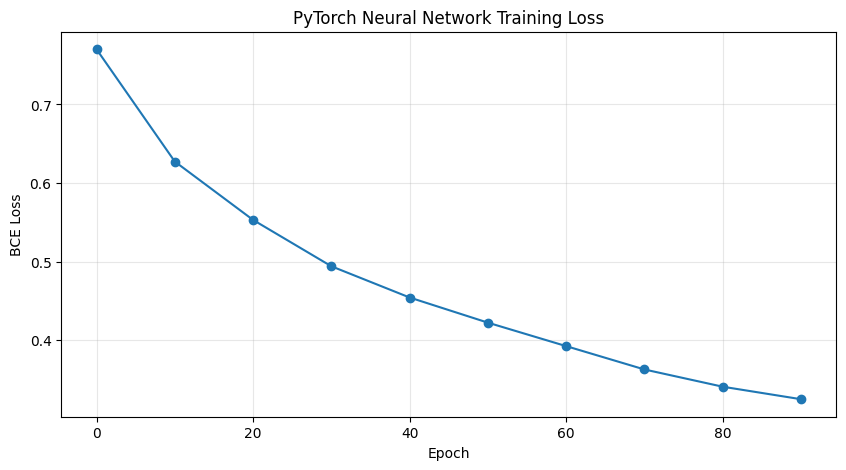

In [12]:
###############################################
########### EC Question 3.2 - 10 pts #########
###############################################

import torch
import torch.nn as nn
import torch.optim as optim

# Prepare PyTorch datasets from the ensemble data
X_train_torch = torch.FloatTensor(X_train_ec)
y_train_torch = torch.FloatTensor(y_train_ec).reshape(-1, 1)
X_test_torch = torch.FloatTensor(X_test_ec)
y_test_torch = torch.FloatTensor(y_test_ec).reshape(-1, 1)

################################################
########## SOLUTION ###########################
################################################

# Define a neural network class
class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNet, self).__init__()
        # Define layers
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        """Forward pass through the network."""
        # Pass through layer1
        out = self.layer1(x)
        # Apply ReLU
        out = self.relu(out)
        # Pass through layer2
        out = self.layer2(out)
        # Apply sigmoid
        out = self.sigmoid(out)
        return out

# Create the model
input_size = X_train_ec.shape[1]
hidden_size = 10
output_size = 1

model = TwoLayerNet(input_size, hidden_size, output_size)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 100
train_losses = []

model.train()  # Set to training mode
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)
    
    # Backward pass and optimization
    optimizer.zero_grad()  # Zero the gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update weights
    
    # Record loss every 10 epochs
    if epoch % 10 == 0:
        train_losses.append(loss.item())

################################################
########## End of solution ####################
################################################

# Evaluate the trained model
model.eval()  # Set to evaluation mode
with torch.no_grad():
    train_pred = (model(X_train_torch) >= 0.5).float()
    test_pred = (model(X_test_torch) >= 0.5).float()
    
    train_acc = (train_pred == y_train_torch).float().mean().item()
    test_acc = (test_pred == y_test_torch).float().mean().item()

print(f'\nPyTorch Neural Network Results:')
print('=' * 50)
print(f'  Training Accuracy: {train_acc:.4f}')
print(f'  Test Accuracy: {test_acc:.4f}')

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(0, epochs, 10), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('PyTorch Neural Network Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

### EC 3.2 Conceptual Questions (5 pts)

**a) (2 pts)** What is the main advantage of using PyTorch (or any automatic differentiation framework) compared to manually implementing backpropagation? Beyond convenience, what does this enable for research?

**b) (2 pts)** Why do we call `optimizer.zero_grad()` at the start of each training iteration? What would happen if we forgot this step?

**c) (1 pt)** What is the difference between `model.train()` and `model.eval()` modes in PyTorch? When should each be used?

**SOLUTIONS:**

**a) Advantages of automatic differentiation:**

Beyond the obvious convenience of not having to manually derive and code gradients, automatic differentiation (autodiff) frameworks like PyTorch enable rapid experimentation with novel architectures and loss functions. Researchers can focus on designing new model components without worrying about deriving correct backward pass equations, which is error-prone and time-consuming. Autodiff also handles complex computational graphs with dynamic control flow, making it possible to build sophisticated architectures like attention mechanisms, recursive networks, and differentiable algorithms that would be extremely difficult to implement with manual backprop. Additionally, autodiff ensures numerical correctness and can automatically leverage optimizations like GPU acceleration and mixed-precision training.

**b) Why zero_grad() is necessary:**

We call `optimizer.zero_grad()` because PyTorch accumulates gradients by default: each time we call `.backward()`, it adds the new gradients to any existing gradients in the parameter tensors. This accumulation is useful for some advanced techniques (like gradient accumulation for large batches), but for standard training, we want each batch's gradients computed independently. If we forgot to call `zero_grad()`, gradients would accumulate across iterations, leading to incorrect gradient values that combine information from multiple batches, causing erratic training behavior, exploding gradients, and failure to converge properly.

**c) train() vs eval() modes:**

`model.train()` sets the model to training mode, where layers like Dropout and BatchNorm behave in their training configuration (Dropout randomly drops neurons, BatchNorm uses batch statistics and updates running statistics). `model.eval()` sets the model to evaluation mode, where Dropout is disabled (all neurons active) and BatchNorm uses the stored running statistics instead of batch statistics, ensuring deterministic and consistent predictions. Use `train()` during training and `eval()` during validation, testing, and inference.

# Conclusion

Congratulations on completing Homework 4! This assignment covered:

1. **Decision Trees**: You implemented entropy, information gain, and a complete decision tree classifier from scratch, gaining deep understanding of how these fundamental ML algorithms work.

2. **Neural Networks**: You implemented forward propagation, performed manual calculations to verify your understanding, and explored the mathematics of backpropagation.

3. **Ensemble Methods**: You compared bagging, random forests, and boosting, learning how combining multiple models improves performance.

4. **Modern Deep Learning**: You implemented neural networks in PyTorch, experiencing the power of automatic differentiation and modern ML frameworks.

These core concepts form the foundation of machine learning and will serve you well in more advanced topics!